In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset reading

In [2]:
PATH = "./data/fitness_dataset.csv"

In [3]:
csv = pd.read_csv(PATH)
df = pd.DataFrame(csv)

In [4]:
df.count()

age                  2000
height_cm            2000
weight_kg            2000
heart_rate           2000
blood_pressure       2000
sleep_hours          1840
nutrition_quality    2000
activity_index       2000
smokes               2000
gender               2000
is_fit               2000
dtype: int64

In [5]:
df.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


In [6]:
input_columns = [
    "age",
    "height_cm",
    "weight_kg",
    "heart_rate",
    "blood_pressure",
    "sleep_hours",
    "nutrition_quality",
    "activity_index",
    "smokes",
    "gender",
]

In [7]:
numerical_columns = [
    "age",
    "height_cm",
    "weight_kg",
    "heart_rate",
    "blood_pressure",
    "sleep_hours",
    "nutrition_quality",
    "activity_index",
]
categorical_columns = ["smokes", "gender"]

## Remove NaN values and smoke attribute fix

In [8]:
df = df[df[input_columns].notna().all(axis=1)]

In [9]:
df["smokes"] = df["smokes"].map({"yes": 1, "no": 0, "0": 0, "1": 1})

In [10]:
df.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,1,F,1
5,25,172,85,81.2,119.2,7.7,7.35,4.08,1,M,0
6,78,193,83,79.6,132.5,7.4,2.16,3.42,1,F,0


In [11]:
df.count()

age                  1840
height_cm            1840
weight_kg            1840
heart_rate           1840
blood_pressure       1840
sleep_hours          1840
nutrition_quality    1840
activity_index       1840
smokes               1840
gender               1840
is_fit               1840
dtype: int64

## Attribute analysis

### Numerical attributes

count    1840.000000
mean       49.135870
std        17.950116
min        18.000000
25%        34.000000
50%        49.000000
75%        65.000000
max        79.000000
Name: age, dtype: float64


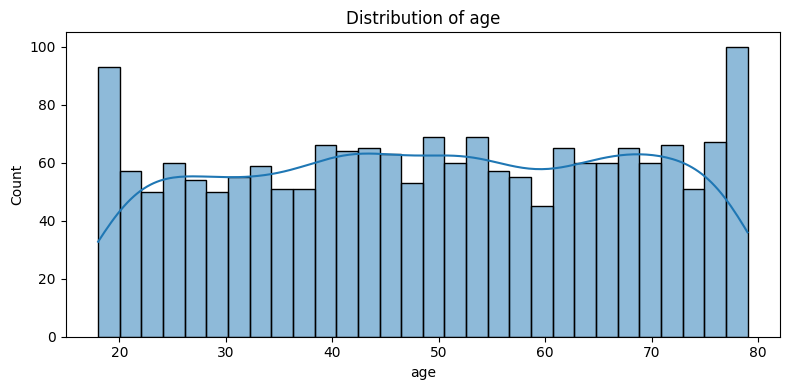

count    1840.00000
mean      174.50163
std        14.40100
min       150.00000
25%       162.00000
50%       174.00000
75%       187.00000
max       199.00000
Name: height_cm, dtype: float64


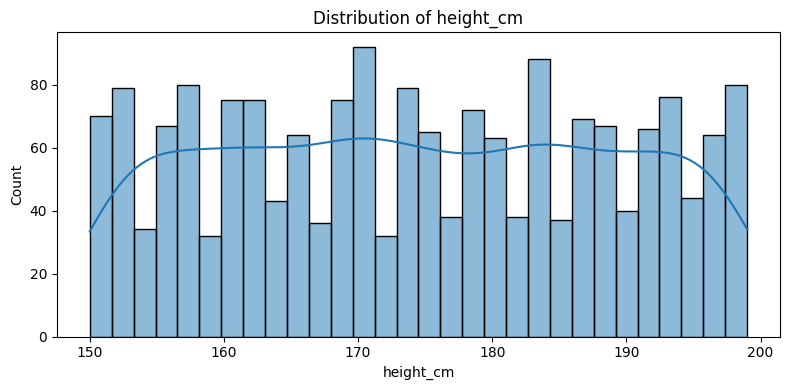

count    1840.000000
mean       83.789130
std        25.776407
min        30.000000
25%        64.000000
50%        83.000000
75%       102.000000
max       250.000000
Name: weight_kg, dtype: float64


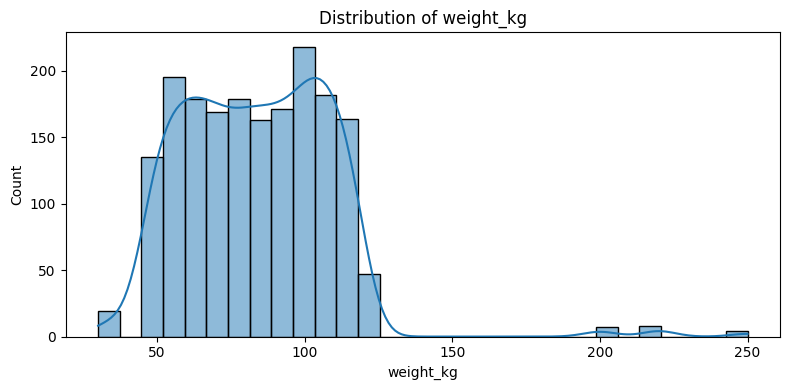

count    1840.000000
mean       70.196576
std        11.783745
min        45.000000
25%        62.100000
50%        70.100000
75%        78.300000
max       118.600000
Name: heart_rate, dtype: float64


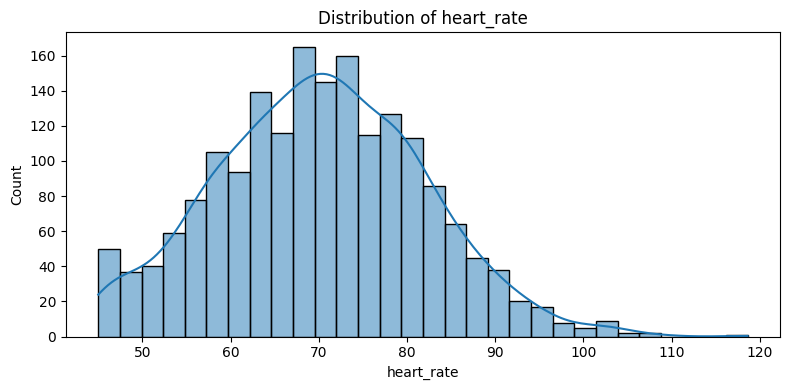

count    1840.000000
mean      119.886304
std        14.499130
min        90.000000
25%       109.800000
50%       119.800000
75%       129.800000
max       171.200000
Name: blood_pressure, dtype: float64


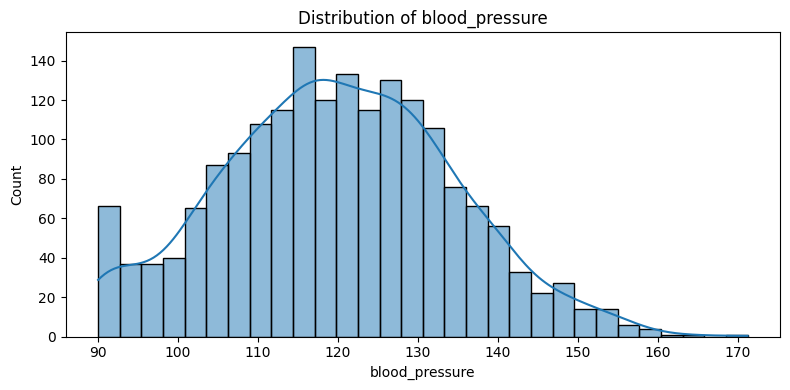

count    1840.000000
mean        7.513315
std         1.502031
min         4.000000
25%         6.500000
50%         7.500000
75%         8.600000
max        12.000000
Name: sleep_hours, dtype: float64


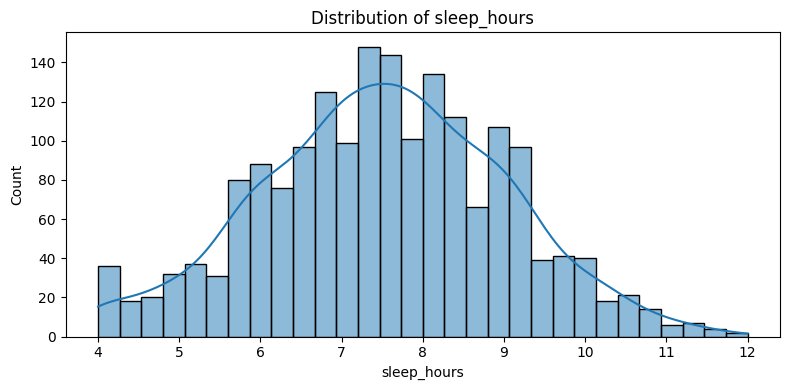

count    1840.000000
mean        5.023924
std         2.865756
min         0.000000
25%         2.547500
50%         5.050000
75%         7.462500
max        10.000000
Name: nutrition_quality, dtype: float64


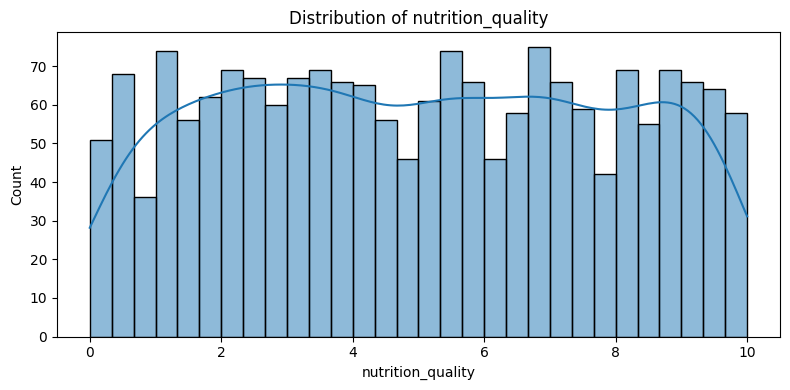

count    1840.000000
mean        2.998114
std         1.132126
min         1.000000
25%         2.047500
50%         2.990000
75%         3.930000
max         4.990000
Name: activity_index, dtype: float64


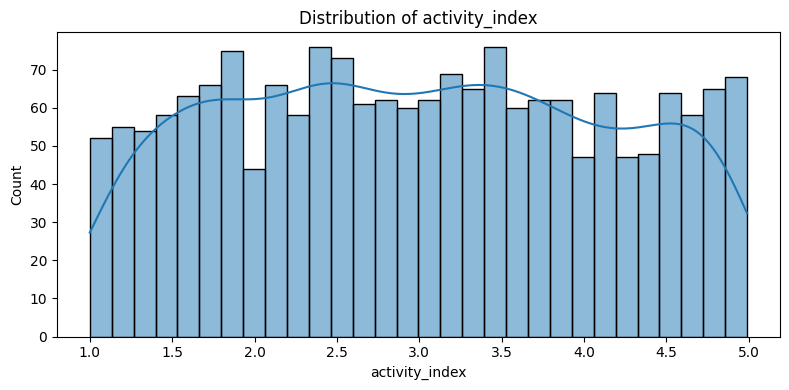

In [12]:
for col in numerical_columns:
    print(df[col].describe())
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

### Categorical attributes

smokes
0    1019
1     821
Name: count, dtype: int64


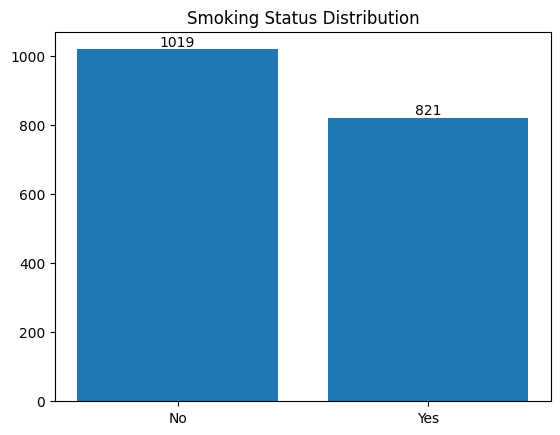

In [13]:
smokes = df["smokes"]
print(smokes.value_counts())
counts = smokes.value_counts().values
bars = plt.bar(["No", "Yes"], counts)
plt.title("Smoking Status Distribution")

# Add values above the bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom')

### Gender

gender
F    954
M    886
Name: count, dtype: int64


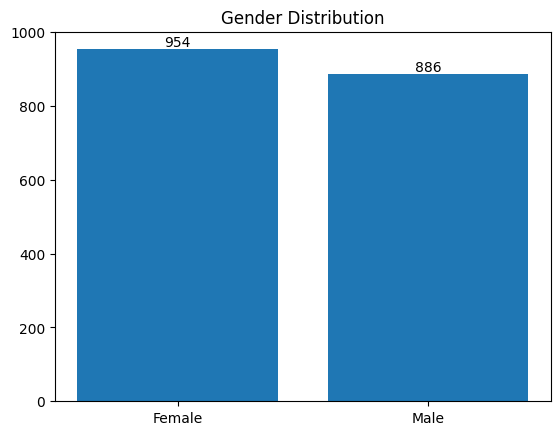

In [14]:
gender = df["gender"]
print(gender.value_counts())
counts = gender.value_counts().values
bars = plt.bar(["Female", "Male"], counts)
plt.title("Gender Distribution")

# Add values above the bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom')

### Target attribute

is_fit
0    1107
1     733
Name: count, dtype: int64


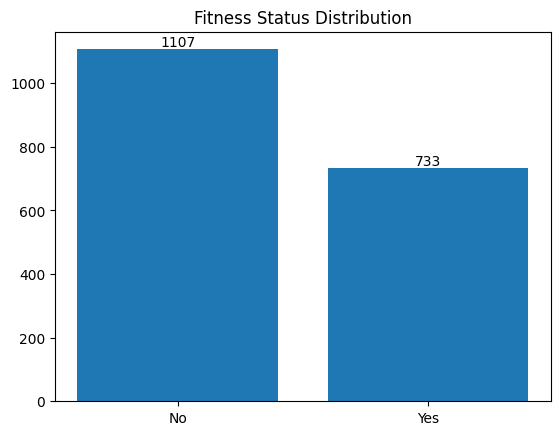

In [15]:
is_fit = df["is_fit"]
print(is_fit.value_counts())
counts = is_fit.value_counts().values
bars = plt.bar(["No", "Yes"], counts)
plt.title("Fitness Status Distribution")

# Add values above the bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom')

## Correlation analysis

                        age  height_cm  weight_kg  heart_rate  blood_pressure  \
age                1.000000   0.015988   0.027727   -0.023953       -0.027294   
height_cm          0.015988   1.000000   0.006460   -0.012178       -0.062364   
weight_kg          0.027727   0.006460   1.000000   -0.011468       -0.005316   
heart_rate        -0.023953  -0.012178  -0.011468    1.000000        0.021780   
blood_pressure    -0.027294  -0.062364  -0.005316    0.021780        1.000000   
sleep_hours       -0.032821  -0.001521   0.006629   -0.004804       -0.008802   
nutrition_quality  0.008484   0.023956  -0.001195    0.002157       -0.020293   
activity_index     0.031754   0.026980  -0.023776    0.031193       -0.000400   
smokes            -0.007771   0.010872   0.036916    0.002832       -0.026041   
is_male            0.001432  -0.028667  -0.013050    0.027084       -0.004912   
is_fit            -0.220018   0.062712  -0.079371    0.033473       -0.055285   

                   sleep_ho

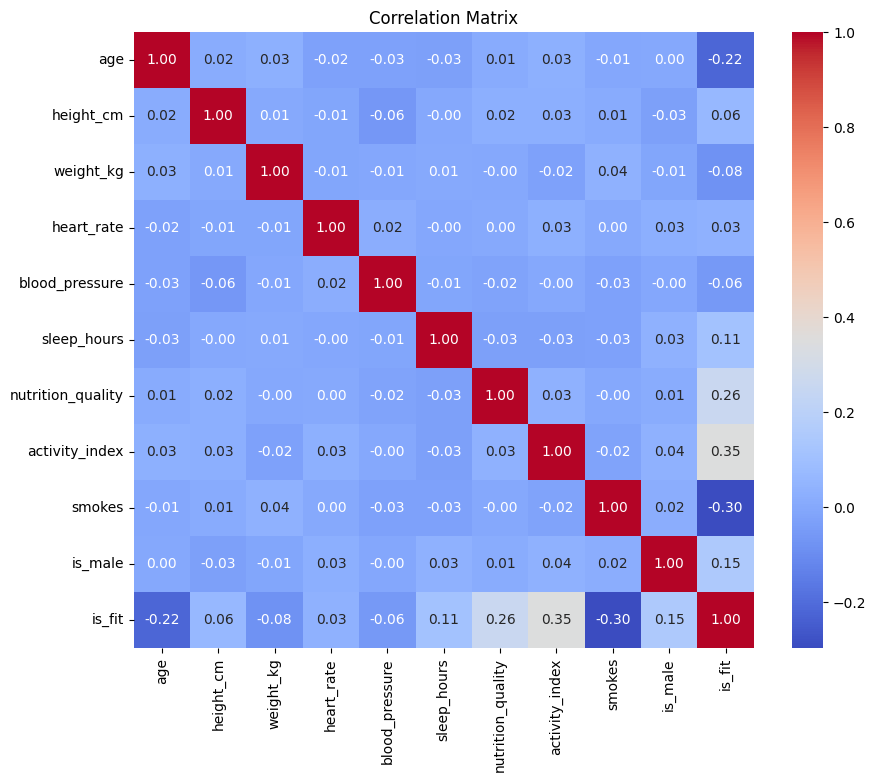

In [16]:
df["is_male"] = df["gender"].map({"F": 0, "M": 1})

df = df[[col for col in df.columns if col != "is_fit"] + ["is_fit"]] # Move target column to the end
correlation_matrix = df.drop(columns=["gender"]).corr()
print(correlation_matrix)

# Optionally, visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()